<a href="https://colab.research.google.com/github/roser740/Data-Analytics/blob/main/TASQUES%20S9/TS9_01_roser_carrera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Tasca S9.01. Visualització de Dades amb Python i Power BI**

En aquest sprint treballaràs la interpretació analítica i el storytelling basat en dades, podràs utilitzar la base de dades que tens disponible a BigQuery o bé la base de dades creada amb MySQL al Sprint 2, a partir de l’exercici 8, i aprendràs a construir visualitzacions en Python com a alternativa programàtica a les eines de BI.

L'objectiu és aprendre a generar gràfics en Python i utilitzar-los per respondre preguntes de negoci. A més, hauràs de justificar les decisions preses i comunicar els resultats de manera clara i argumentada.

El teu paper com a analista serà:

» Entendre què se t'està preguntant des del punt de vista del negoci.

» Decidir quines visualitzacions són adequades per respondre cada pregunta.

» Construir aquestes visualitzacions en Python.

» Interpretar correctament què mostren les dades.

» Detectar possibles biaixos, limitacions o riscos en l'anàlisi.

» Proposar accions de negoci fonamentades en dades.

Aquest sprint posa l'èmfasi en l'ús de Python com a eina d'anàlisi visual, en el criteri analític i en la capacitat de transformar gràfics en decisions, més que en la sofisticació tècnica. Procura que el teu codi sigui clar i organitzat.

🔴🟠🔵🟣🟡🟤⚫⚪🟥🟧🟨🟩🟦🟪🟫⬛⬜

## ⭕ **Algoritme principal**

## 🧠 **Algoritme inicial**

## 🧩 **Implementació de les visualitzacions**

## ▶ **Execució**

# **📚 Connexió amb MySQL**

Per connectar Google Colab amb MySql hem seguit els següents passos:
1. Instal·lació de Jupyter Notebook des del terminal: *py -m pip install notebook*
2. Iniciació del pont local des del terminal: *py -m notebook --no-browser --NotebookApp.allow_origin="https://colab.research.google.com" --NotebookApp.allow_credentials=True --port=8888 --NotebookApp.port_retries=0*
3. Connexió de Google Colab a un entorn d'execució local
4. Comprovació de la connexió local:



In [476]:
import os
import socket
import sys

print("Equip:", socket.gethostname())
print("Python:", sys.executable)
print("Usuari:", os.getenv("USERNAME") or os.getenv("USER"))

Equip: DESKTOP-M6GB2OT
Python: C:\Users\PC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe
Usuari: PC


5. Instal·lació de les llibreries per poder connectar amb MySQL: *%pip install sqlalchemy pymysql*
6. Configuració de la connexió amb MySQL i comprovació:


In [477]:

import pymysql
from sqlalchemy import create_engine

# Substitueix pels teus valors de credencials de MySQL local
USER = "root"  # p. ex. 'root'
PASSWORD = "Cabestany26$"
HOST = "127.0.0.1"
PORT = 3306  # Port
DATABASE = "vendes"

# Opció amb SQLAlchemy (Recomanada)
connection = (f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}")
engine = create_engine(connection)

# Comprovar connexió
with engine.connect() as conn:
    print("Connexió establerta correctament amb SQLAlchemy!")

Connexió establerta correctament amb SQLAlchemy!


# **📚 Llibreries**

Abans d'importar les llibreries les hem instal·lat a l'entorn local seguint les següents instruccions:

%pip install pandas

%pip install matplotlib

%pip install seaborn

Un cop fet això ja podem importar les llibreries que necessitem per fer els exercicis:


In [509]:
import pandas as pd
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

import seaborn as sns
import seaborn.objects as so


## **💢 Estructures de dades**

Carreguem en diferents datafremes les taules de transacions, companyies, productes i usuaris de la base de dades ***vendes*** que tenim a MySQL. Visualitzem una mostra de les dades que ens anirà bé per resoldre els exercicis.

In [510]:
df_trans = pd.read_sql("SELECT * FROM transactions;", con=engine)
df_comp = pd.read_sql("SELECT * FROM companies;", con=engine)
df_prod = pd.read_sql("SELECT * FROM products;", con=engine)
df_trans_prod = pd.read_sql("SELECT * FROM transaction_products;", con=engine)
df_users = pd.read_sql("SELECT * FROM users;", con=engine)

mostrar_dataframe (df_trans.head(), "MOSTRA DEL DATAFRAME DE TRANSACCIONS")
mostrar_dataframe(df_comp.head(),"MOSTRA DEL DATAFRAME DE COMPANYIES")
mostrar_dataframe(df_prod.head(),"MOSTRA DEL DATAFRAME DE PRODUCTES")
mostrar_dataframe(df_trans_prod.head(),"MOSTRA DEL DATAFRAME DE TRANSACCIONS I PRODUCTES")
mostrar_dataframe(df_users.head(),"MOSTRA DEL DATAFRAME DE USUARIS")


MOSTRA DEL DATAFRAME DE TRANSACCIONS


,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,discount_amount,tax_amount,shipping_amount,channel,campaign_id,device_type,is_international,decline_reason,distance_km
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,34.17,72.25,0.00,online,SUMMER_TRAVEL,mobile,0,,59.95
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.7573,-95.37960,16.10,22.47,0.00,store,SUMMER_TRAVEL,pos,1,,1157.10
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,175.00,0,72,2115,53.5489,-113.50300,1.05,14.45,0.00,store,NO_CAMPAIGN,pos,0,,540.32
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,158.55,0,18,3025,52.2084,5.69081,25.31,25.96,8.99,marketplace,WINTER_SALE,desktop,0,,28.52
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,CcU-3358,b-2598,2023-09-23 04:51:43,317.97,0,"35, 33, 19",215,53.5535,-113.49900,2.87,26.25,0.00,store,NO_CAMPAIGN,pos,0,,539.82



MOSTRA DEL DATAFRAME DE COMPANYIES


,company_id,company_name,phone,email,country,website,merchant_category,merchant_price_position
0,b-2222,Ac Fermentum Incorporated,+64 601 244 6320,donec.porttitor.tellus@yahoo.net,Germany,https://www.ac-fermentum-incorporated.com,Beauty,mid-market
1,b-2226,Magna A Neque Industries,+33 823 560 3779,risus.donec.nibh@icloud.org,Australia,https://www.magna-a-neque-industries.com,Travel,budget
2,b-2230,Fusce Corp.,+29 657 646 4324,risus@protonmail.edu,United States,https://www.fusce-corp.com,Home,mid-market
3,b-2234,Convallis In Incorporated,+6 693 982 1255,mauris.ut@aol.couk,Germany,https://www.convallis-in-incorporated.com,Sports,mid-market
4,b-2238,Ante Iaculis Nec Foundation,+69 914 549 1009,sed.dictum.proin@outlook.ca,New Zealand,https://www.ante-iaculis-nec-foundation.com,Toys,mid-market



MOSTRA DEL DATAFRAME DE PRODUCTES


,id,product_name,price,colour,weight,warehouse_id,category,brand,cost,launch_date
0,1,Direwolf Stannis,161.11,#7c7c7c,1.0,WH-4,Sports,Runway Pro,63.84,2014-11-01
1,2,Tarly Stark,9.24,#919191,2.0,WH-3,Gaming,Questbyte,4.74,2013-02-07
2,3,duel tourney Lannister,171.13,#d8d8d8,1.5,WH-2,Food,Daily Pantry,107.07,2013-08-18
3,4,warden south duel,71.89,#111111,3.0,WH-1,Books,NorthPress,39.17,2013-12-31
4,5,skywalker ewok,171.22,#dbdbdb,3.2,WH-0,Home,NordHaus,83.69,2014-07-17



MOSTRA DEL DATAFRAME DE TRANSACCIONS I PRODUCTES


,id_transaction,id_product
0,001A60EA-DC9C-4E5A-9460-6628B100E7E1,1
1,0032F0BB-BBE6-4AA5-B5EE-EEAD533C0C48,1
2,00342381-503D-422D-85AB-F2D4FFAAD4C7,1
3,004C0A80-E537-46D8-BE44-343D2176DF15,1
4,004D1DB5-B2CB-4460-98B6-31C42CA96E5F,1



MOSTRA DEL DATAFRAME DE USUARIS


,id,name,surname,phone,email,birth_date,country,city,postal_code,address,signup_date,user_segment,income_band
0,1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,"Nov 17, 1985",United States,New York,10001,348-7818 Sagittis St.,2014-04-23,young_professional,high
1,2,Garrett,Mcconnell,(718) 257-2412,integer.vitae.nibh@protonmail.org,"Aug 23, 1992",United States,Philadelphia,19101,903 Sit Ave,2014-07-04,young_professional,high
2,3,Ciaran,Harrison,(522) 598-1365,interdum.feugiat@aol.org,"Apr 29, 1998",United States,Houston,77001,736-2063 Tellus St.,2014-02-15,frequent_shopper,high
3,4,Howard,Stafford,1-411-740-3269,ornare.egestas@icloud.edu,"Feb 18, 1989",United States,Phoenix,85001,Ap #545-2244 Erat. Rd.,2014-08-21,premium,high
4,5,Hayfa,Pierce,1-554-541-2077,et.malesuada.fames@hotmail.org,"Sep 26, 1998",United States,Philadelphia,19101,341-2821 Ultrices Av.,2013-04-28,frequent_shopper,high


Generem un dataframe seleccionant només les **transaccions acceptades** ja que en molts exercicis ens cal mostrar resultats relacionats amb les vendes que han arribat a bon port.

El camp **declined** ens indica si una transacció és rebutjada (declined=1) o acceptada (declined=0).

El dataframe de transaccions té 99.999 registres i el de transaccions acceptades en té 99.111. Això vol dir que hi ha 888 transaccions rebutjades que no cal contemplar quan analitzem vendes reals.

In [480]:
df_trans_acceptades = df_trans[df_trans['declined']==0]

# **♻ Re-utilització de funcions:**

Utilitzarem funcions que tenim definides d'altres esprints.

In [481]:
def mostrar_dataframe(df, títol):
#Presenta les dades en format tabular amb el títol indicat

    # Mostrem títol
    print("\n" + "="*100)
    print(títol)
    print("="*100)
    # La funció display mostra les dades del dataframe en format taula.
    display(df)

# **Nivell 1 - Visualització analítica guiada en Python**


L'objectiu del nivell és aplicar criteri analític per respondre preguntes de negoci mitjançant visualitzacions en Python, treballant amb les taules del model del Sprint 2 a partir de l’exercici 8, carregades com a DataFrame independents.

En aquest nivell no es demana construir un dataset final ni unificar totes les taules, sinó:

» Identificar quina informació és necessària.

» Escollir correctament la taula (o taules) rellevant(s).

» Construir visualitzacions adequades.

» Interpretar els resultats obtinguts.

Aquest nivell posa l'èmfasi en pensar abans de programar.

# **Exercici 1: Preguntes analítiques directes (sense integracions complexes)**

🌍 **Context:** Es treballa amb una sola taula a la vegada, escollida segons la pregunta analítica. No cal fer merge entre taules ni definir funcions avançades.

**Aspectes a revisar i analitzar:**

» Identificar quina informació és necessària. Quin DataFrame és el més adequat per respondre la pregunta.

» Escollir correctament la taula (o taules) rellevant(s).

» Tipus de variables implicades.

» Elecció del tipus de gràfic.

**Preguntes analítiques:**(només utilitzant la taula de transaccions) :

1. Com evoluciona el **nombre de transaccions** al llarg del temps? Exemple de passos guiats amb pandas.
    *   Selecciona la columna temporal adequada.
    *   Defineix el nivell temporal d'anàlisi.
    *   Compta el nombre de registres per període temporal.
    *   Ordena els resultats cronològicament.
    *   Visualitza l'evolució amb un gràfic de línies amb pandas.

2. Quins usuaris generen més **volum de facturació**? Exemple de passos guiats amb seaborn.
    *   Identifica la columna que representa el usuari.
    *   Agrupa les transaccions per usuari i calcula el volum total de facturació sumant la columna amount.
    *   Ordena els usuaris de major a menor volum de facturació.
    *   Selecciona els N usuaris principals (per exemple, els 15 primers).
    *   Representa el resultat mitjançant un gràfic de barres utilitzant Seaborn

3. Hi ha diferències en la **distribució de l'import** de les transaccions segons l'hora del dia i si han estat acceptades o rebutjades? Exemple de passos guiats amb seaborn.
    *   Crea una nova columna amb l'hora del dia a partir del timestamp.
    *   Utilitza un violinplot de seaborn per analitzar la distribució dels imports.
    *   Assigna: x per l'hora del dia, y per l'import de la transacció i hue per l'estat de la transacció.
    *   Activa split per comparar acceptades i rebutjades i inner amb quartile per mostrar mediana i quartils.

4. Quins dies de la setmana es concentra més **activitat de venda**?

👉 **Per a cada pregunta:**

  *   Construeix una visualització senzilla en Python sense utilitzar IA.
  *   Interpreta breument el resultat obtingut.
  *   Utilitza les eines d'IA disponibles a Colab per proposar una visualització alternativa.
  *   Compara el resultat inicial amb el resultat proposat per la IA i valora críticament si la nova proposta és una millora o un empitjorament, justificant la teva decisió

# **Disseny i implementació de la solució**

### ***1. Evolució de les transaccions al llarg del temps***


**Objectiu:** analitzar com evoluciona el nombre de transaccions al llarg del temps.

**Observacions:**
*   Utilitzem la columna **timestamp** que guarda la data i hora de cada transacció per extreure l'any.
*   Seleccionem les transaccions amb **declined = 0** ja que suposem que interessa valorar les transaccions acceptades i no les rebutjades. El fet de parlar de transaccions sense especificar crea una mica de confusió.

🟢**Generació de les dades i el gràfic**      

In [482]:
# GENERACIÓ DE LES DADES ##########################################

def generar_dades_1_1 (df_trans):
  # Comptem els número de transaccions acceptades realitzades cada any. Ordenem per índex per poder mostrar els resultats cronològicament.
  anys = df_trans['timestamp'].dt.year.value_counts().sort_index()

  return anys

In [520]:
# GENERACIÓ DEL GRÀFIC ##########################################

def generar_grafic_1_1 (anys):

  # Defninim la mida del gràfic
  plt.figure(figsize=(12, 6))

  # Generem un gràfic de línies
  anys.plot(kind='line', marker='o')

  # Mostrem títol i etiquetes dels eixos
  plt.title('Evolució del Nombre de Transaccions al llarg dels anys')
  plt.xlabel('Any')
  plt.ylabel('Nombre de Transaccions')

  # Mostrem graella del fons
  plt.grid(True, linestyle='--', alpha=0.7)

  # Ajustem marges i espais del gràfic
  plt.tight_layout()
  plt.show()

🟢**Execució**

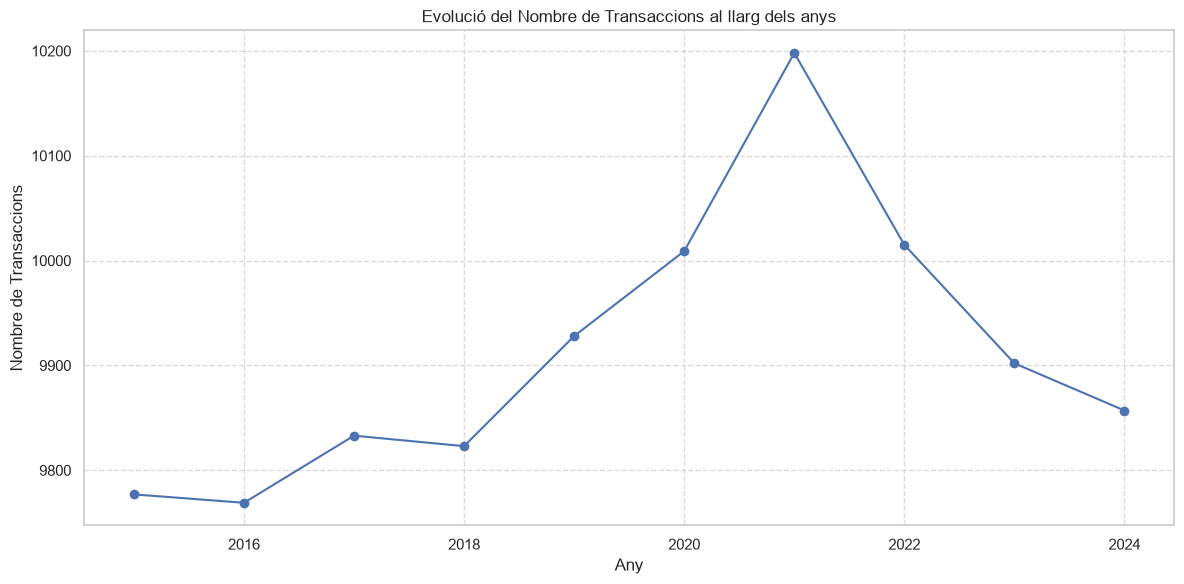

In [521]:
anys = generar_dades_1_1(df_trans_acceptades)
generar_grafic_1_1(anys)

🟢**Interpretació**  


Aquest gràfic de línies mostra l'evolució del nombre de transaccions al llarg dels anys des del 2015 al 2024.

En aquest gràfic observem:
*   un **creixement** del nombre de transaccions des del 2015 al 2021. El creixement és més suau els primers anys i més pronunciat a partir del 2018.
*   a l'any 2021 el nombre de transaccions assoleix un **valor màxim** d'aproximadament 10200 transaccions.
*   a partir de l'any 2021 hi ha un **decreixement** del nombre de transaccions fins a assolir l'any 2024 valors propers a l'any 2019.

Tot i que visualment sembla que el creixement i el decreixement són molt grans cal tenir en compte l'escala de l'eix vertical. Veiem que els valors no comencen des de 0. Així la diferència entre el valor més baix i el més alt és d'un 4% aproximadament.



🟢**Visualització alternativa amb IA**  

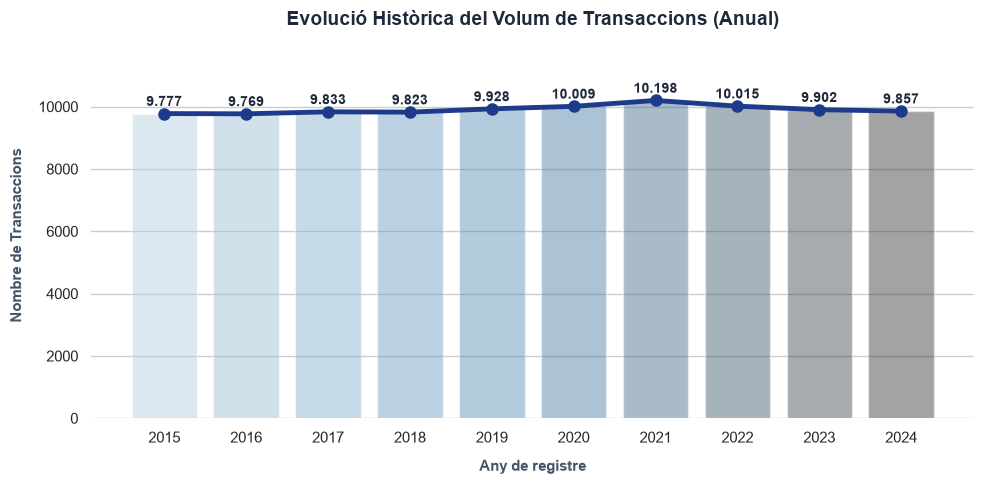

In [485]:
# Calculem el nombre de transaccions per any
anys_vendes = df_trans[df_trans['declined']==0]['timestamp'].dt.year.value_counts().sort_index().reset_index(name='transaccions')
anys_vendes.columns = ['Any', 'Transaccions']

# Configurem un disseny visual molt més net i professional
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# Creem un gràfic de barres elegant de fons per donar context de volum
ax = sns.barplot(
    data=anys_vendes,
    x='Any',
    y='Transaccions',
    palette='Blues_d',
    alpha=0.45,
    hue='Any',
    legend=False
)

# Superposem la línia de tendència de color intens per marcar l'evolució clarament
plt.plot(
    range(len(anys_vendes)),
    anys_vendes['Transaccions'],
    color='#1e3a8a',
    linewidth=3.5,
    marker='o',
    markersize=8,
    label='Tendència'
)

# Afegim etiquetes amb els valors a sobre de cada punt per a una lectura ràpida
for i, valor in enumerate(anys_vendes['Transaccions']):
    plt.text(
        i,
        valor + (max(anys_vendes['Transaccions']) * 0.015),
        f"{valor:,}".replace(',', '.'),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#1e293b'
    )

# Personalització de títols i eixos
plt.title('Evolució Històrica del Volum de Transaccions (Anual)', fontsize=14, fontweight='bold', pad=20, color='#1e293b')
plt.xlabel('Any de registre', fontsize=11, fontweight='bold', labelpad=10, color='#475569')
plt.ylabel('Nombre de Transaccions', fontsize=11, fontweight='bold', labelpad=10, color='#475569')

# Ajustos finals de neteja visual
plt.ylim(0, max(anys_vendes['Transaccions']) * 1.15)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

🟢**Comparació**  

Gemini ens proposa com a alternativa un diagrama de barres amb un gràfic de línies superposat.

Aquest gràfic representa una millora respecte a l'anterior en termes de rigor analític i de comunicació de dades (Data Storytelling) concretament en els següents aspectes:
*   **L'eix y comença des de 0**. Això permet apreciar la magnitud real de les dades: el volum de transaccions és extremadament estable al llarg dels 10 anys, amb variacions mínimes entre el punt més baix i el més alt. Evita transmetre una falsa sensació de volatilitat o crisi.
*   **Etiquetes de dades**. Inclou la xifra exacta a la part superior de cada barra/punt. Aquest fet millora la legibilitat immediata i evita que l'usuari hagi de fer estimacions visuals.
*   Suporposa un **gràfic de línies** a les barres que, tot i ser redundant, mostra més clarament l'evolució.

D'altra banda la utilització d'una seqüència de **colors degradats** a les barres crea una mica de confusió ja que pot semblar que les barres més fosques corresponen a un valor més elevat i no és així.




### ***2. Top 15 de volum de facturació per usuari***

**Objectiu:** mostrar quins usuaris generen més volum de facturació.

**Observacions:**
*   Agrupem per la columna **user_id** que guarda el codi de l'usuari que ha realitzat la transacció.  
*   Seleccionem les transaccions amb **declined = 0** ja que per calcular el volum de facturació només cal tenir en compte les transaccions acceptades.
  

🟢**Generació de les dades i el gràfic**  

In [486]:
# GENERACIÓ DE LES DADES ##########################################

def generar_dades_1_2 (df_trans):

  # Agrupem per usuari, sumem import, ordenem de major a menor facturació i seleccionem els 15 primers
  usuaris = df_trans.groupby(['user_id'])['amount'].sum().sort_values(ascending=False).head(15)
  # Convertim a un dataframe de dues columnes
  usuaris = usuaris.reset_index(name="facturacio_total")

  return usuaris

In [519]:
# GENERACIÓ DEL GRÀFIC ##########################################

def generar_grafic_1_2 (usuaris):

  # Defninim la mida del gràfic
  plt.figure(figsize=(12, 6))

  # Convertim la columna 'user_id' numèrica a tipus categòric de text per evitar ordenacions numèriques automàtiques
  usuaris['user_id'] = usuaris['user_id'].astype(str)

  # Creem el gràfic de barres mantenint l'ordre del dataframe
  sns.barplot(
      data=usuaris,
      x="user_id",
      y="facturacio_total",
      order=usuaris["user_id"])  # Mantenim l'ordre de major a menor facturació)

  # Mostrem el títol del gràfic i les etiquetes dels eixos
  plt.title("Top 15 de facturació per usuari")
  plt.ylabel("Facturació Total (€)")
  plt.xlabel("Codis d'usuari")

  # Ajustem marges i espais del gràfic
  plt.tight_layout()
  plt.show()

🟢**Execució**  

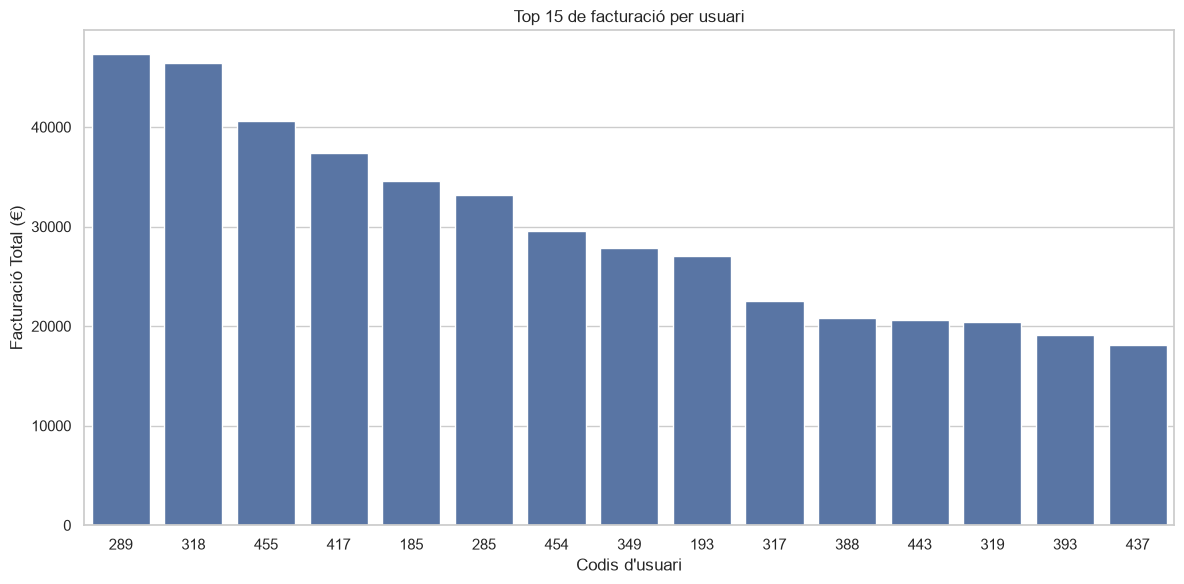

In [522]:
usuaris = generar_dades_1_2(df_trans_acceptades)
generar_grafic_1_2(usuaris)

🟢**Interpretació**  

Aquest gràfic de barres mostra el Top 15 d'usuaris que generen més ingressos, ordenats de major a menor segons la seva facturació total en euros.

En aquest gràfic observem 3 grups d'usuaris:
*   Dos usuaris **líders** amb més de 45.000€ de facturació cadascun.
*   Un grup **intermedi** de 7 usuaris amb una facturació de 25.000€ a 40.000€.
*   Un tram **baix** de 6 usuaris amb una facturació al voltant de 20.000€

S'observa una caiguda gradual i bastant suau en la facturació a mesura que avancem del 1r al 15è usuari. No hi ha cap usuari "gegant" desproporcionat que tot sol representi el 80% del Top 15, tot i que els dos primers destaquen notablement.

A nivell de disseny observem que el gràfic comença adequadament des de 0 €, evitant distorsions visuals en les proporcions reals.


🟢**Visualització alternativa amb IA**  

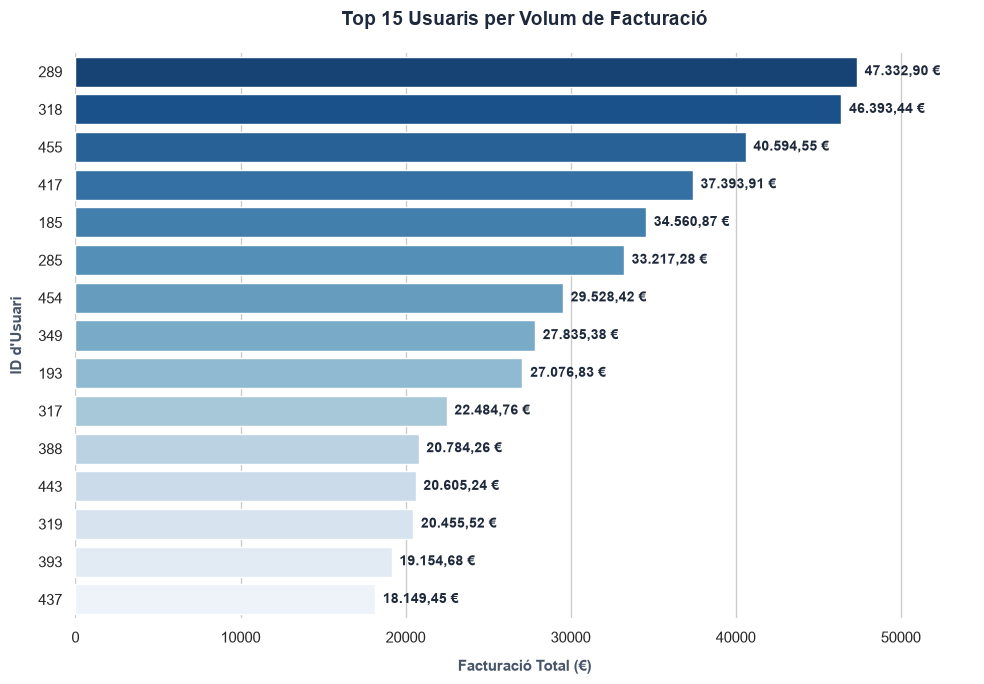

In [489]:

# Preparem les dades del Top 15 (assegurem ID com a text i ordenació correcta)
usuaris_alt = usuaris.copy()
usuaris_alt['user_id'] = usuaris_alt['user_id'].astype(str)
usuaris_alt = usuaris_alt.sort_values(by='facturacio_total', ascending=False)

# Configurem l'estil net i professional
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

# Generem un degradat perfecte de color blau per a 15 barres (de fosc a clar)
colors_degradat = sns.color_palette("Blues_r", n_colors=15)

# Creem el gràfic de barres horitzontals
ax = sns.barplot(
    data=usuaris_alt,
    y="user_id",
    x="facturacio_total",
    order=usuaris_alt["user_id"],
    palette=colors_degradat,
    hue="user_id",
    legend=False
)

# Afegim els valors exactes de facturació al final de cada barra
for i, valor in enumerate(usuaris_alt['facturacio_total']):
    ax.text(
        valor + (max(usuaris_alt['facturacio_total']) * 0.01),  # Petit marge a la dreta de la barra
        i,                                                     # Posició vertical de la barra
        f"{valor:,.2f} €".replace(',', 'X').replace('.', ',').replace('X', '.'),  # Format de moneda en català
        va='center',
        fontsize=10,
        fontweight='bold',
        color='#1e293b'
    )

# Personalitzem els eixos i el títol
plt.title("Top 15 Usuaris per Volum de Facturació", fontsize=14, fontweight='bold', pad=20, color='#1e293b')
plt.xlabel("Facturació Total (€)", fontsize=11, fontweight='bold', labelpad=10, color='#475569')
plt.ylabel("ID d'Usuari", fontsize=11, fontweight='bold', labelpad=10, color='#475569')

# Ampliem el límit de l'eix X per allotjar còmodament les etiquetes de text
plt.xlim(0, max(usuaris_alt['facturacio_total']) * 1.15)

# Eliminem les línies del marc que no aporten valor
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

🟢**Comparació**  

Gemini ens proposa com a alternativa un gràfic de barres horitzontals.

Aquest gràfic representa una millora respecte a l'anterior en els següents aspectes:
*   El format **horitzontal** permet llegir les etiquetes dels eixos i dels valors de manera més natural sense haver de rotar els textos.
*   **Etiquetes de valors**: inclou la xifra exacta a la part dreta de cada barra per tal d'evitar que l'usuari hagi de fer estimacions visuals.
*   Paleta de **blaus degradats**: reforça visualment l'ordre decreixent ja que els tons blaus foscos identifiquen ràpidament els usuaris amb més volum de facturació.  


### ***3. Distribució de l'import segons l'hora i l'estat***

**Objectiu**: analitzar si hi ha un patró en la distribució de l'import de les transaccions segons l'hora del dia i l'estat.

🟢**Visualització**  

In [517]:
# GENERACIÓ DEL GRÀFIC ##########################################

def generar_grafic_1_3 (df_trans):
  # Creem una columna per guardar l'hora
  df_trans['hora'] = df_trans['timestamp'].dt.hour

  # Defninim la mida del gràfic
  plt.figure(figsize=(12, 6))

  # Creem el violinplot per analitzar la distribució dels imports
  sns.violinplot(x=df_trans['hora'],
               y=df_trans['amount'],
               hue=df_trans['declined'],
               split = True,
               inner = 'quartile',
               cut = 0)

  # Mostrem el títol del gràfic i les etiquetes dels eixos
  plt.title("Distribució de l'import segons l'hora i l'estat")
  plt.ylabel("Import transacció (€)")
  plt.xlabel("Hores del dia")

  # Ajustem marges i espais del gràfic
  plt.tight_layout()
  plt.show()


🟢**Execució**  

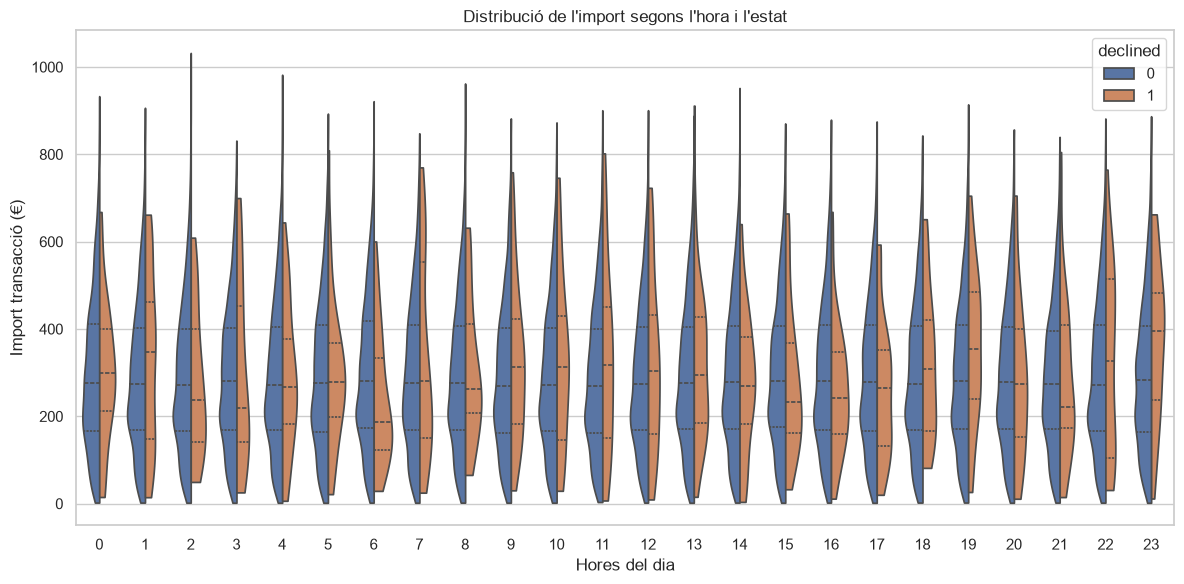

In [518]:
generar_grafic_1_3(df_trans)

🟢**Interpretació**  

Aquest **gràfic de violí dividit**  mostra la distribució de l'import de les transaccions en funció de l'hora del dia (0 a 23h) i de l'estat de la transacció (declined).

**Què veiem?**
*   La part blava representa el número de transaccions acceptades.
*   La part taronja representa el número de transaccions rebutjades.
*   L'amplada de la banda ens indica el número de transaccions que hi ha per un import determinat.  
*   Les línies de puntets ens indiquen els quartils (mediana i rang interquartílic del 25% i 75%) de la distribució per a cada grup.

**Què deduim?**
*   **Absència de patró temporal:** la forma i amplada de la part blava dels violins(operacions acceptades) és molt semblant a totes les hores del dia. Observem que la mediana (línia central puntejada) i els quartils de les transaccions acceptades són pràcticament equivalents en gairebé totes les hores. Així la part més ampla dels violins es troba entre 100€ i 400€. Això vol dir que en totes les hores del dia la majoria de les transaccions es troba en aquests imports.
*   **Outliers:** les cues dels violins pugen fins a 800€ o 1000€. Això ens indica que hi ha transaccions puntuals d'alt import.
*   **Rebutjades:** la part taronja dels violins és més prima i té una forma més allargada en la majoria dels casos. Això ens indica que hi ha ménys operacions rebutjades que acceptades i que hi ha més variabilitat en els imports (de 100€ a 600€).Això vol dir que l'import de la transacció no sembla ser un factor determinant per al rebuig de l'operació. Els rebutjos afecten tant comandes petites com grans de la mateixa manera al llarg de tot el dia.


🟢**Visualització alternativa amb IA**  

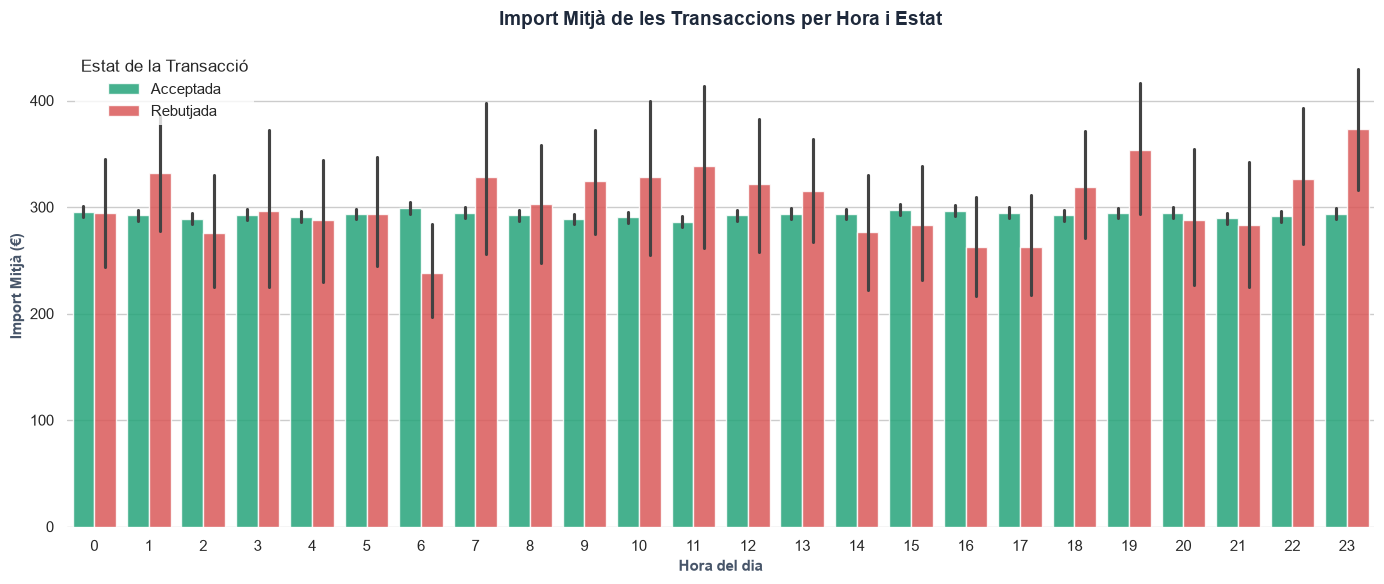

In [492]:

# Preparem una còpia de les dades per a la visualització
df_hora_estat = df_trans.copy()
df_hora_estat['estat'] = df_hora_estat['declined'].map({0: 'Acceptada', 1: 'Rebutjada'})

# Configurem l'estil visual net
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# Creem un gràfic de barres per comparar les mitjanes d'import amb intervals de confiança
ax = sns.barplot(
    data=df_hora_estat,
    x='hora',
    y='amount',
    hue='estat',
    palette={'Acceptada': '#10b981', 'Rebutjada': '#ef4444'},  # Verd per acceptat, Vermell per rebutjat
    alpha=0.85,
    errorbar=('ci', 95)  # Mostra l'interval de confiança del 95% per veure la variabilitat
)

# Personalització de títols i etiquetes
plt.title("Import Mitjà de les Transaccions per Hora i Estat", fontsize=14, fontweight='bold', pad=15, color='#1e293b')
plt.xlabel("Hora del dia", fontsize=11, fontweight='bold', color='#475569')
plt.ylabel("Import Mitjà (€)", fontsize=11, fontweight='bold', color='#475569')

# Llegenda polida
plt.legend(title="Estat de la Transacció", frameon=True, facecolor='white', edgecolor='none')

# Neteja de línies de marc innecessàries
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

🟢**Comparació**  

Gemini ens proposa com a visualització alternativa un **gràfic de barres d'import mitjà per hora**, desglossat per l'estat de la transacció (Acceptada vs Rebutjada). També mostra les **barres d'error** amb un interval de confiança del 95%. Les barres d'error curtes indiquen una precisió alta en l'estimació de la mitjana (hi ha un volum elevat de dades que confirma aquesta xifra). Una barra d'error llarga significa que hi ha molta variabilitat en els imports d'aquella hora o que hi ha poques transaccions registrades en aquesta mostra.

En comparar els dos gràfics podem dir que en funció de l'objectiu que tinguem serà millor un o l'altre.

Si volem fer un **anàlisi exhaustiu** de la distribució de les vendes al llarg del dia és millor el gràfic de violí ja que és més complet. El gràfic de violí mostra tota la densitat de la distribució(mediana, quartils, outliers) en canvi en aquest gràfic només veiem l'import mitjà de les transaccions a cada hora i l'interval de confiança del 95% d'aquesta estimació.

Si volem fer una **presentació de l'informació** que sigui clara, entenedora i ràpida d'interpretar és millor el segon gràfic ja que té menys informació però la mostra d'una manera més clara. El gràfic de violí pot resultar difícil de llegir i interpretar de forma ràpìda



### ***4. Distribució de la venda segons el dia de la setmana***

**Objectiu:** analitzar la distribució de la venda segons el dia de la setmana.

**Observacions:**

Per mesurar l'activitat de venda en funció del dia de la setmana podem utilitzar diferents mètriques:
*   mitjana del número de tiquets per dia de la setmana
*   mitjana de la facturació per dia de la setmana

Generem les dades calculant les dues mètriques i decidim que farem un gràfic a partir de la mitjana de facturació.

🟢**Generació de les dades i el gràfic**  

In [493]:
# GENERACIÓ DE LES DADES ##########################################

def generar_dades_1_4 (df_trans):

  # Creem diccionari amb el nom dels dies en català
  mapa_dies = {
      0: 'Dilluns',
      1: 'Dimarts',
      2: 'Dimecres',
      3: 'Dijous',
      4: 'Divendres',
      5: 'Dissabte',
      6: 'Diumenge',
  }

  # Creem columnes per guardar data, número i nom del dia de la setmana
  df_trans['data'] = df_trans['timestamp'].dt.date
  df_trans['num_dia'] = df_trans['timestamp'].dt.dayofweek
  df_trans['dia'] = df_trans['num_dia'].map(mapa_dies)

  # Agrupem per data, número i nom del dia de la setmana i comptem transaccions acceptades i facturació total
  tiquets_per_data = df_trans.groupby(['data', 'num_dia', 'dia']).agg(num_tiquets=('id', 'count'), facturacio_total=('amount', 'sum')).reset_index()

  # Agrupem per dia de la setmana i calculem la mitjana de transaccions i de facturació
  tiquets_per_dia = tiquets_per_data.groupby(['num_dia','dia']).agg(mitjana_tiquets=('num_tiquets', 'mean'), mitjana_facturacio=('facturacio_total', 'mean')).round(2)
  tiquets_per_dia = tiquets_per_dia.reset_index().sort_values('num_dia')

  return tiquets_per_dia


In [523]:

# GENERACIÓ DEL GRÂFIC ##########################################

def generar_grafic_1_4 (tiquets_per_dia):

  # Defninim la mida del gràfic
  plt.figure(figsize=(12, 6))

  # Creem el gràfic de barres per mostrar la mitjana de facturació en funció del dia de la setmana
  sns.barplot(
    data=tiquets_per_dia,
    x="dia",
    y="mitjana_facturacio",
    dodge=False,  # <-- evita que les columnes es facin primes
    width=0.7     # <-- controla l'amplada de les barres
  )

  # Mostrem el títol del gràfic i les etiquetes dels eixos
  plt.ylabel("Facturació Mitjana(€)")
  plt.xlabel("Dia de la setmana")
  plt.title("Distribució de venda per dia de la setmana")

  # Ajustem marges i espais del gràfic
  plt.tight_layout()
  plt.show()

🟢**Execució**  

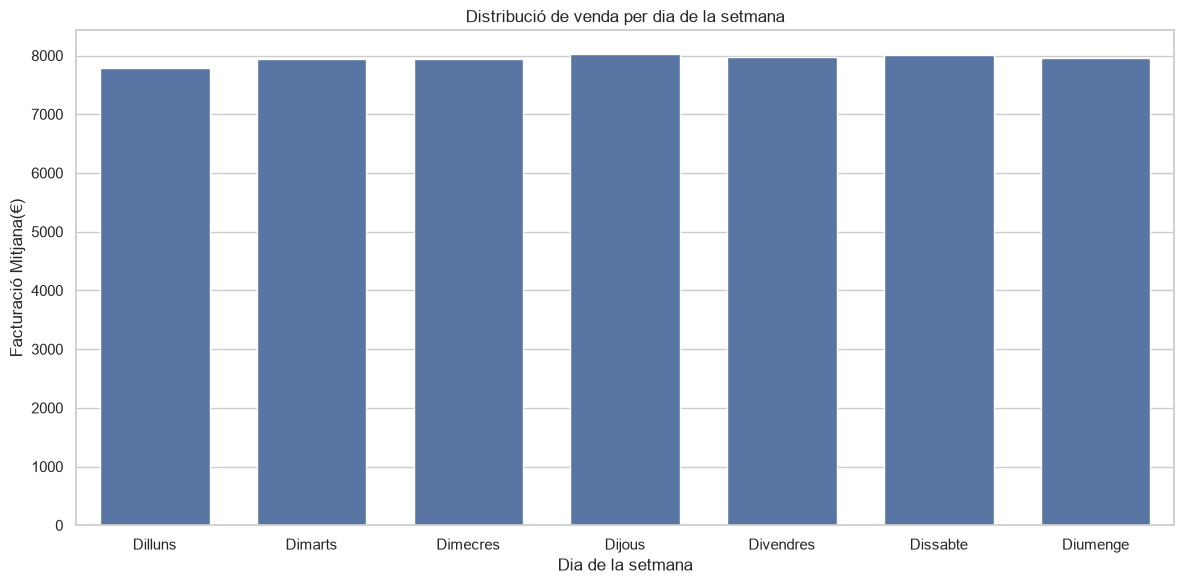

In [524]:
tiquets_per_dia = generar_dades_1_4(df_trans_acceptades)
generar_grafic_1_4(tiquets_per_dia)

🟢**Interpretació**  

Aquest gràfic de barres mostra la facturació mitjana en funció del dia de la setmana.

Observem que la facturació és molt semblant en tots els dies però si filem prim detectem que els últims dies de la setmana a partir del dijous la facturació és una mica més gran.De totes maneres estem parlant de diferències no significatives que no ens permeten definir cap patró.

🟢**Visualització alternativa amb IA**  

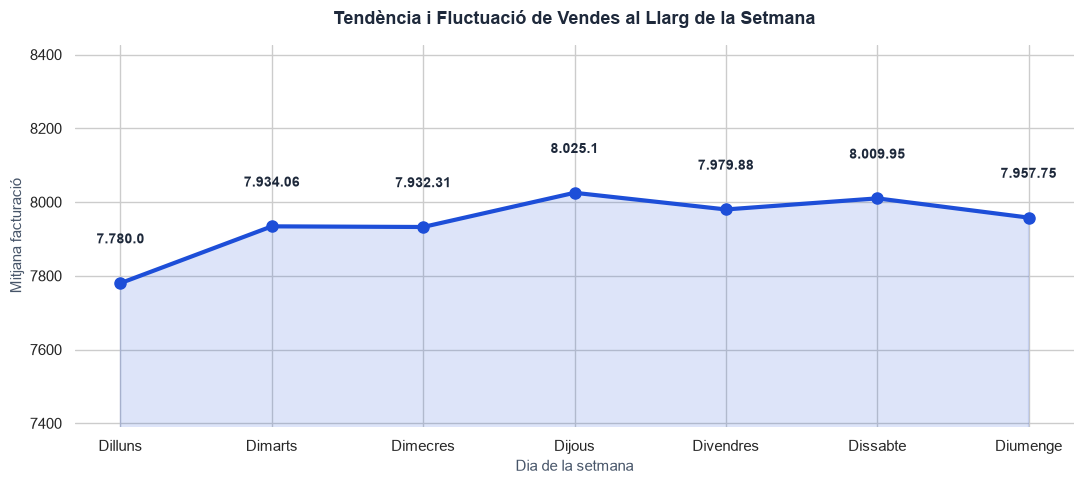

In [496]:

# Preparem les dades ordenades de dilluns a diumenge
df_linia = tiquets_per_dia.copy()

# Configurem l'estil net i professional
plt.figure(figsize=(11, 5))
sns.set_theme(style="whitegrid")

# 1. Dibuixem la línia de tendència principal
plt.plot(
    df_linia['dia'],
    df_linia['mitjana_facturacio'],
    color='#1d4ed8',      # Blau corporatiu intens
    linewidth=3,
    marker='o',
    markersize=8,
    label='Transaccions'
)

# 2. Afegim un ombrejat suau a sota de la línia per donar sensació de volum d'activitat
plt.fill_between(
    df_linia['dia'],
    df_linia['mitjana_facturacio'],
    color='#1d4ed8',
    alpha=0.15
)

# 3. Etiquetem directament els punts clau per evitar que l'usuari hagi de mirar constantment l'eix Y
for i, valor in enumerate(df_linia['mitjana_facturacio']):
    plt.text(
        i,
        valor + 100,
        f"{valor:,}".replace(',', '.'),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#1e293b'
    )

# Personalització final estètica
plt.title("Tendència i Fluctuació de Vendes al Llarg de la Setmana", fontsize=13, fontweight='bold', pad=15, color='#1e293b')
plt.xlabel("Dia de la setmana", fontsize=11, color='#475569')
plt.ylabel("Mitjana facturació", fontsize=11, color='#475569')

# Ajustem l'escala de l'eix Y per deixar espai a les etiquetes
plt.ylim(min(df_linia['mitjana_facturacio']) * 0.95, max(df_linia['mitjana_facturacio']) * 1.05)

# Eliminem línies de contorn innecessàries
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

🟢**Comparació**  

Gemini ens proposa un gràfic de línia de tendència setmanal amb un gradient d'àrea ombrejada a sota.

Aquest gràfic representa un empitjorament  respecte a l'anterior en els següents aspectes:
*   **Escala eix vertical:** l'escala de l'eix vertical no comença al 0 i això distorsiona la lectura de les dades. Sembla que hi ha molta variació quan en realitat és la diferència és molt petita.
*   **Línea contínua:** els gràfics de línies s'han d'utilitzar per a sèries temporals contínues (ex. evolució dia a dia al llarg dels mesos o anys). En aquest cas, com que estem fent una agrupació per dia no és adequada.

Com a aspecte positiu podem destacar les **etiquetes de dades** que ens permeten una lectura directa dels valors sense haver-los d'estimar.

# **Exercici 2: Preguntes analítiques complexes (amb guia)**

🌍 **Context:** Aquest exercici requereix combinar informació de diverses taules del model per poder respondre correctament les preguntes.

**Aquí sí que serà necessari:**

» Fer merge entre taules.

» Utilitzar groupby, pivot_table, crosstab...

» Aplicar agregacions, transformacions intermèdies i funcions.

**Preguntes analítiques (amb guia general)**

**» Depenem excessivament d'un nombre reduït de països de companyies venedores?**

Passos orientatius:

1. Combinar la informació de transaccions amb la de companyies.

2. Agrupar la facturació per país.

3. Calcular la facturació total generada per cada país.

4. Ordenar els països de major a menor facturació.

5. Calcular el percentatge acumulat sobre el total.

6. Visualitzar.

**» Existeix estacionalitat en les vendes?**

Passos orientatius:

1. Treballar amb dates de transacció.

2. Extreure la informació temporal rellevant (any i mes).

3. Calcular el volum total de vendes (suma de amount) per any i mes.

4. Comparar patrons temporals amb la comparació entre anys. Crea una taula tipus pivot.

5. Visualitzar l'evolució.

**» Anàlisi de concentració i variabilitat (tria UNA opció)**

**Opció A** – Producte (Només si disposes de la taula de productes)

Quins productes generen més ingressos i amb quina variabilitat?

Passos orientatius:

1. Combinar transaccions, la taula pont i productes.

2. Calcular ingressos per producte amb un groupby, sum y sort.

3. Selecciona els top N productes: 15 per exemple.

4. Escollir una visualització adequada per analitzar dispersió.

**Opció B** – Activitat d'usuaris (Alternativa si no disposes de la taula de productes)

Hi ha usuaris que han deixat de comprar recentment?

Passos orientatius:

1. Identificar l'última compra per usuari.

2. Calcular el temps des de l'última compra.

3. Visualitzar la distribució del temps des de l'última compra.

**» Com varia l'activitat de venda per franges horàries al llarg dels anys? (patrons horaris)**

Passos orientatius:

1. Crear franges horàries a partir de l'hora: crea una funció i aplica-la utilitzant apply.

2. Construir una taula agregada utilitzant crosstab.

3. Visualitzar amb un heatmap.

👉 **Per a cada pregunta:**

» Descriu breument els passos seguits.

» Mostra la visualització final.

» Interpreta què implica per al negoci.

# **Disseny i implementació de la solució**

### ***1. Dependència de companyies vendedores***

**Objectiu:** avaluar si existeix una dependència excessiva de determinats països venedors.

**Passos:**
*   Generar una taula amb el volum de facturació total per país, el percentatge que representa cada país respecte el total i el percentatge acumulat.
*   Generar un gràfic de Pareto amb les barres de facturació per país i una línia amb el percentatge acumulat.

El **gràfic de Pareto** permet veure immediatament si un pocs països concentren la majoria del negoci.


🟢**Generació de les dades**  

In [497]:
def generar_dades_2_1 (df_trans, df_comp):

  # Combinem les dades de transaccions i companyies
  # inner i left  donen el mateix num de registres. Existeixen totes les companyies
  df_merge = pd.merge(df_trans, df_comp, left_on='business_id', right_on='company_id',how = 'inner')

  # Agrupem per país i sumem facturació. Seleccionem transaccions acceptades. El groupby ens retorna serie. Esborrem index per convertir a dataframe
  df_pais = df_merge.groupby(['country'])['amount'].sum().sort_values(ascending=False).reset_index(name="facturacio_total")

  # Calculem la facturació global total
  total_global = df_pais["facturacio_total"].sum()

  # Calculem el percentatge individual respecte al total
  df_pais["per_relatiu"] = (df_pais["facturacio_total"] / total_global) * 100

  # Calculem el percentatge acumulat (cumsum)
  df_pais["per_acumulat"] = df_pais["per_relatiu"].cumsum()

  # Mostrem les dades obtingudes
  mostrar_dataframe (df_pais, "FACTURACIÓ PER PAÍS")

  return df_pais


🟢**Generació del gràfic**


In [498]:
def generar_grafic_2_1 (df_pais):

  # Creem i inicialitzem la figura i l'eix principal del gràfic. Definim les dimensions del gràfic
  fig, ax1 = plt.subplots(figsize=(12, 6))

  # Eix 1: Barres de facturació per país
  sns.barplot(
      data=df_pais,
      x="country",
      y="facturacio_total",
      ax=ax1,
      palette="Blues_r",
      hue="country",
      legend=False
  )

  # Mostrem títol del gràfic i etiquetes dels eixos
  ax1.set_title("Anàlisi de Concentració de Facturació per País Venedor", fontsize=14, pad=15)
  ax1.set_ylabel("Facturació Total (€)", color="navy", fontsize=12)
  ax1.set_xlabel("Països", color="navy", fontsize=12)

  # Inclinem els valors de l'eix horitzontal per tal que no es solapin
  ax1.tick_params(axis="x", rotation=45)

  # Eix 2: Línia del percentatge acumulat
  ax2 = ax1.twinx()
  ax2.plot(
      df_pais["country"],
      df_pais["per_acumulat"],
      color="red",
      marker="o",
      linewidth=2,
      label="% Acumulat",
  )

  # Etiqueta del segon eix vertical
  ax2.set_ylabel("Percentatge Acumulat (%)", color="red", fontsize=12)
  ax2.set_ylim(0, 105)

  # Línia de referència de l'80% (Regla de Pareto)
  ax2.axhline(80, color="orange", linestyle="--", alpha=0.7, label="Llindar 80%")

  # Grid del fons
  plt.grid(axis="y", linestyle=":", alpha=0.6)

  # Ajustem marges i espais del gràfic
  plt.tight_layout()
  plt.show()



🟢**Execució**


FACTURACIÓ PER PAÍS


,country,facturacio_total,per_relatiu,per_acumulat
0,Sweden,4884077.83,16.827020,16.827020
1,Netherlands,4470873.59,15.403415,32.230435
2,United Kingdom,4065098.37,14.005406,46.235841
3,Italy,4061060.93,13.991495,60.227336
4,Germany,3984664.03,13.728287,73.955623
5,France,1406668.15,4.846367,78.801990
6,United States,1085266.88,3.739049,82.541039
7,Belgium,937789.26,3.230947,85.771986
8,Norway,798331.87,2.750478,88.522464
9,Ireland,707379.30,2.437120,90.959584


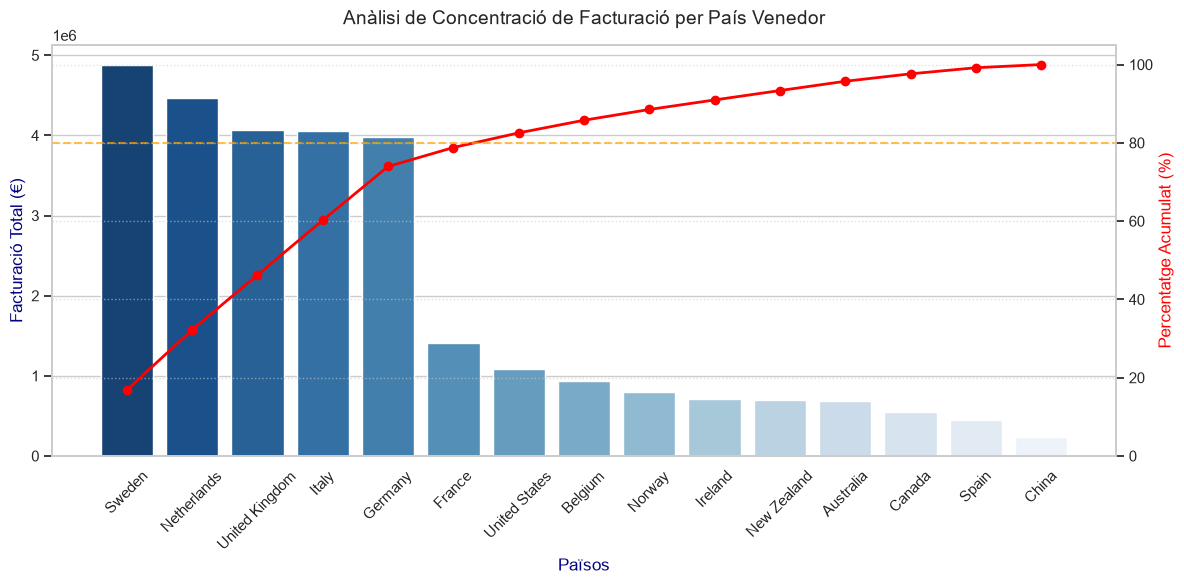

In [499]:
df_pais = generar_dades_2_1 (df_trans_acceptades, df_comp)
generar_grafic_2_1 (df_pais)

🟢**Interpretació**


**» Depenem excessivament d'un nombre reduït de països de companyies venedores?**

Existeix dependència excessiva si el top 20% dels països genera el 80% o més de la facturació total.

En el nostre cas observem que els 5 primers països, que representen menys del 40% del total, generen quasi el 80% de la facturació. Així podem dir que existeix **bastanta dependència** d'un nombre reduït de països que a més estan concentrats a **Europa**. Això vol dir que qualsevol canvi regulatori, logístic o crisi econòmica que afecti principalment aquests 5 mercats tindria un impacte immediat i crític en aproximadament el 80% dels ingressos de l'empresa.


### ***2. Estacionalitat de les vendes***


**Objectiu:** analitzar com es comporten els ingressos mes a mes al llarg dels diferents anys.

**Passos:**
*   Generar una taula amb el desglòs de la facturació per mes i any.
*   Generar un gràfic de línies de múltiples sèries (una línia per cada any).

El **gràfic de línies de múltiples sèries** és una bona opció per mostrar l'estacionalitat ja que si les línies de diferents anys tenen forma o pics similars als mateixos mesos aleshores podem deduit que hi ha estacionalitat.

🟢**Generació de les dades**  


In [500]:
def generar_dades_2_2 (df_trans):
  # Creem columnes al dataframe per capturar l'any i el mes de la data
  df_trans['any'] = df_trans['timestamp'].dt.year
  df_trans['mes'] = df_trans['timestamp'].dt.month

  # Agrupem per any i mes i sumem l'import de la facturació de les transaccions acceptades.
  # Convertim a dataframe
  df_grup = df_trans.groupby(['any','mes'])['amount'].sum().to_frame()
  df_grup.reset_index(inplace=True)

  # Amb la funció pivot convertim la columna de l'any en diverses columnes, una per cada any
  pivot_vendes = df_grup.pivot (index='mes', columns='any', values='amount')

  # Canviem el número de mes pel nom del mes en català a l'índex
  noms_mesos = [
      "Gener",
      "Febrer",
      "Març",
      "Abril",
      "Maig",
      "Juny",
      "Juliol",
      "Agost",
      "Setembre",
      "Octubre",
      "Novembre",
      "Desembre",
  ]
  pivot_vendes.index = [noms_mesos[i - 1] for i in pivot_vendes.index]

  # Mostrem les dades obtingudes
  mostrar_dataframe (pivot_vendes, "VENDES PER MENSUAL PER ANYS")

  return pivot_vendes


🟢**Generació del gràfic**

In [501]:
def generar_grafic_2_2 (pivot_vendes):

  # Definim les dimensions del gràfic
  plt.figure(figsize=(12, 6))

  # Dibuxem una línia per a cada any
  for columna_any in pivot_vendes.columns:
      plt.plot(
          pivot_vendes.index,
          pivot_vendes[columna_any],
          marker="o",
          linewidth=2,
          label=str(columna_any),
      )

  # Mostrem el títol del gràfic i les etiquetes dels eixos
  plt.title("Evolució Mensual de les Vendes per Any (Anàlisi d'Estacionalitat)", fontsize=14, pad=15)
  plt.xlabel("Mes", fontsize=12)
  plt.ylabel("Volum Total de Vendes (€)", fontsize=12)

  # Rotem les etiquetes de l'eix horitzontal per tal que no es solapin
  plt.xticks(rotation=45)

  # Definim la graella de fons i la llegenda
  plt.grid(axis="both", linestyle="--", alpha=0.5)
  plt.legend(title="Any")

  # Ajustem marges i espais del gràfic
  plt.tight_layout()
  plt.show()

🟢**Execució**


VENDES PER MENSUAL PER ANYS


any,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Gener,221978.21,224451.27,222956.21,227411.90,222944.11,231702.95,243339.85,224709.53,228413.66,226393.73
Febrer,245780.13,248112.42,252303.71,245092.09,259807.32,248318.04,257434.31,235427.85,251422.67,249898.07
Març,253000.65,246634.37,237621.09,237099.83,276818.21,258872.56,250861.14,271978.12,241711.00,245792.02
Abril,245597.21,240833.04,251596.72,234246.30,242707.81,244251.90,259770.51,237165.49,241264.06,244769.15
Maig,248585.36,241306.84,240125.80,244448.97,242550.42,253699.74,239662.08,276262.60,261355.45,254122.62
Juny,232624.35,230577.43,240337.61,242769.22,241694.85,236410.96,234080.71,260082.37,232254.56,244370.81
Juliol,241252.27,237081.73,240576.35,231261.73,233513.25,240255.64,251450.91,233349.01,238652.72,230031.53
Agost,233797.97,235600.88,230225.76,228759.89,237070.53,232658.86,237051.75,245198.95,237981.15,236671.63
Setembre,227211.93,241530.84,230606.28,236768.38,232551.83,257964.96,245398.37,254316.72,234226.30,234226.89
Octubre,241722.74,250228.07,240875.48,253827.42,250595.22,258891.46,264897.72,256342.46,250946.37,254314.46


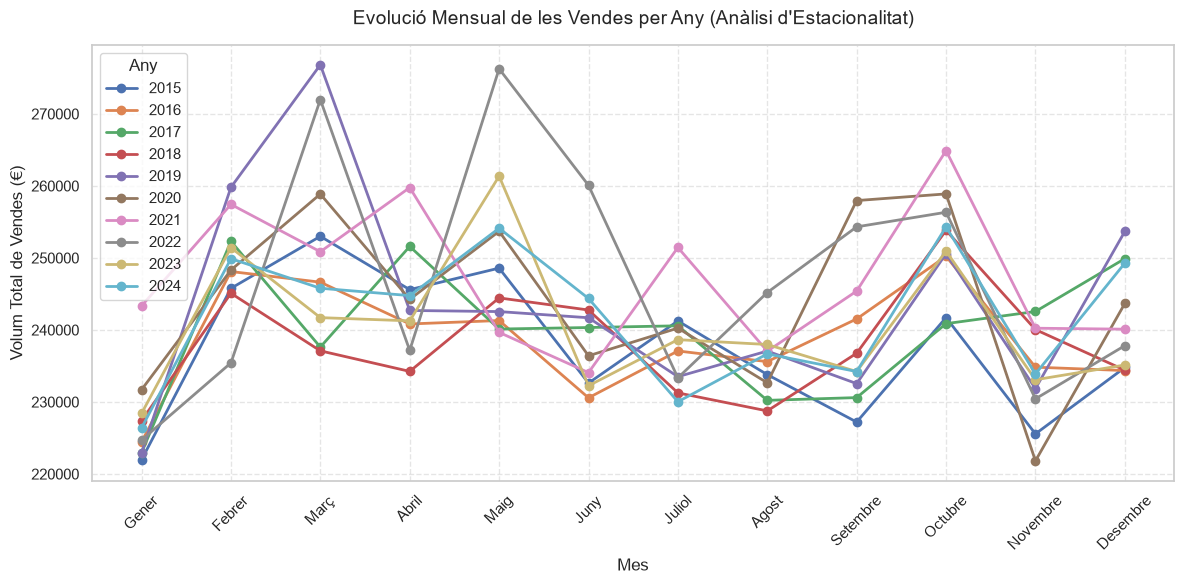

In [502]:
pivot_vendes = generar_dades_2_2 (df_trans_acceptades)
generar_grafic_2_2 (pivot_vendes)

🟢**Interpretació**

**» Existeix estacionalitat en les vendes?**

Tot i que hi ha variabilitat entre anys, s'observen algunes tendències molt clares que es repeteixen pràcticament cada any:  
*   **Baixada pronunciada al Gener:** el mes de Gener és, de manera consistent per a gairebé tots els anys, el punt més baix de facturació de tot l'exercici (al voltant dels 220.000 € - 230.000 €).
*   **Baixada al novembre:** el novembre presenta una altra caiguda notable molt similar a la del gener.
*   **Repunt fort a principis d'any** (Febrer - Març): després del mínim del gener, la facturació experimenta un augment ràpid i fort al Febrer i es manté alt al Març (arribant a fregar o superar els 240.000 € - 260.000 € en la majoria d'anys).
*   **Segon pic a la tardor** (Octubre): després d'uns mesos d'estiu més moderats (Juny a Setembre), el mes d'Octubre torna a registrar de manera molt consistent un pic clar de vendes en gairebé tots els anys de la sèrie

Per tant podem dir que hi ha uns patrons clars d'estacionalitat en les vendes.



### ***3. Anàlisi de concentració i variabilitat de productes***

**Objectiu:** analitzar quins productes generen més ingressos i, alhora, la seva variabilitat/dispersió (saber si la gent compra aquest producte sempre pel mateix import o si l'import de cada comanda canvia molt).

**Passos:**
*   Generar una taula amb els 15 productes que generen més ingressos mostrant la facturació total per producte.
*   Generar un diagrama de barres per mostrar el volum de facturació total per producte ordenat de major a menor ingressos.
*   Generar un diagrama de Caixa (Boxplot) superposat per mostrar la distribució de l'import de les transaccions individuals per cada producte.

Un **Boxplot** és una bona opció per visualitzar la **variabilitat/dispersió** perquè mostra:
*   La mediana de l'import per venda.
*   El rang interquartílic (l'amplada de la caixa = variabilitat habitual).
*   Els valors atípics (outliers): punts que representen comandes excepcionalment grans o petites.

🟢**Generació de les dades**  

In [528]:
def generacio_dades_2_3 (df_trans, df_trans_prod, df_prod):

  # Combinem les dades de la taula de transaccions amb la taula pont
  df_merge = pd.merge(df_trans, df_trans_prod, left_on='id', right_on='id_transaction',how = 'inner')
  # Combinem les dades de la taula anterior amb la taula de productes
  df_merge = pd.merge(df_merge, df_prod, left_on='id_product', right_on='id',how = 'inner')

  # Agrupem per codi producte, sumem import de facturació, ordenem descendent, seleccionem els 15 primers i convertim a dataframe
  df_top_productes = df_merge.groupby(['id_y','product_name'])['amount'].sum().sort_values(ascending=False).head(15).reset_index()
  df_top_productes.columns = ['codi_producte', 'nom_prodcute','facturacio_total']

  # Mostrem les dades obtingudes
  mostrar_dataframe(df_top_productes , "FACTURACIÓ TOP 15 PER PRODUCTE")

  return df_top_productes, df_merge

🟢**Generació del gràfic**


In [529]:
def generacio_grafic_2_3 (df_top_productes, df_merge):

  # Definim les dimensions del gràfic
  fig, ax1 = plt.subplots(figsize=(12, 6))

  # Eix 1: Barres de facturació per producte
  sns.barplot(
      data=df_top_productes,
      x="codi_producte",
      y="facturacio_total",
      order=df_top_productes["codi_producte"],
      ax=ax1,
      color='lightgray',
      alpha=0.6)

  # Mostrem el títol del gràfic i les etiquetes dels eixos
  ax1.set_title("Dispersió i Variabilitat de l'Import per Transacció (Top 15 Productes)",fontsize=14, pad=15)
  ax1.set_xlabel("Codi Producte", fontsize=12)
  ax1.set_ylabel("Facturació Total (€)", fontsize=12)

  # Definim la graella de fons
  plt.grid(axis="y", linestyle=" ", alpha=0.6)

  # Filtrem les transaccions individuals per incloure només els productes del Top 15
  llista_top_15 = df_top_productes["codi_producte"].tolist()
  df_top_15_transaccions = df_merge[df_merge['id_y'].isin(llista_top_15)]

  ax2 = ax1.twinx()

  # Dibuixem el boxplot ordenat de major a menor ingressos totals
  sns.boxplot(
      data=df_top_15_transaccions,
      x="id_y",
      y="amount",
      order=llista_top_15,
      ax=ax2,
      width=0.4)

  ax2.set_ylabel('Import per Transacció (€)', color='blue')

  # Definim la graella de fons
  plt.grid(axis="y", linestyle="--", alpha=0.6)

  # Ajustem marges i espais del gràfic
  plt.tight_layout()
  plt.show()

🟢**Execució**


FACTURACIÓ TOP 15 PER PRODUCTE


,codi_producte,nom_prodcute,facturacio_total
0,67,Winterfell,1141422.71
1,64,Direwolf,1141124.95
2,39,warden,1140988.17
3,12,duel Direwolf,1124248.15
4,93,Littlefinger Tarly Stark,1120366.37
5,15,Stannis warden,1118587.59
6,16,the duel warden,1117757.48
7,62,the duel,1115537.07
8,86,Stark kingsblood,1106871.50
9,68,Stark Karstark,1098600.97


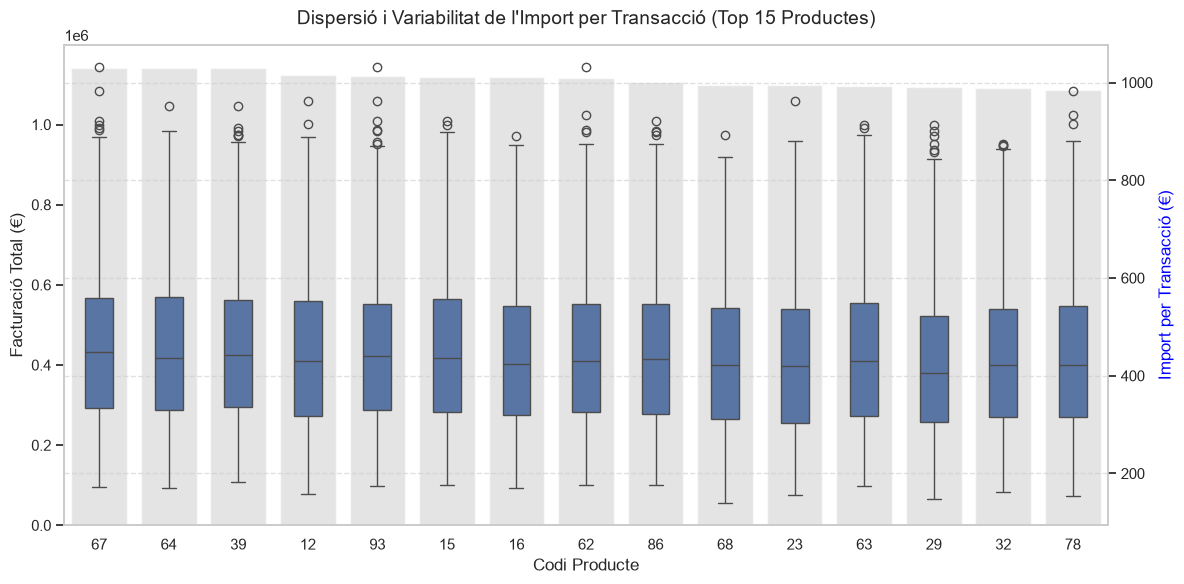

In [531]:
df_top_productes, df_merge = generacio_dades_2_3 (df_trans_acceptades, df_trans_prod, df_prod)
generacio_grafic_2_3 (df_top_productes, df_merge)

🟢**Interpretació**

**Quins productes generen més ingressos i amb quina variabilitat?**

El gràfic mostra el 15 productes que generen més ingressos ordenats de major a menor volum de facturació.

En el **gràfic de barres** observem que la facturació està molt repartida i és homogènia entre els 15 principals productes ( al voltant de 1,1 milions d'euros per producte). No hi ha un únic producte que sostingui l'empresa de manera aïllada.

En el **gràfic de caixa(boxplot)** observem que els 15 principals productes tenen un perfil molt semblant pel que fa a la dispersió d'import per transacció:
*   la majoria de les transaccions es situen entre 300€ i 550€ aproximadament.
*   un 25% es situen entre 100€ i 300€ aproximadament.
*   un altre 25% es situen entre 550€ i 900€ aproximadament.
*   hi ha outliers puntuals al voltant dels 1000€

Així podem dir que els 15 productes que generen més ingressos es venen de manera constant i estable amb quantitats semblants a cada transacció.

### ***4. Anàlisi de patrons horaris***


**Objectiu:**  analitzar com es distribueix l'activitat de venda segons el moment del dia i com ha evolucionat aquesta distribució amb el temps.

**Passos:**
*   Crear les franges horàries
*   Generar una taula amb el percentatge de facturació per franja sobre el total per any.
*   Crear una mapa de calor (heatmap) per visualitzar ràpidament en quina franja es concentra l'activitat de venda per cada any.

Per mesurar l'activitat de venda podem escollir com a criteri el nombre de vendes o bé la facturació en cada franja. En el nostre cas hem escollit la facturació.

🟢**Generació de les dades**  


In [506]:

def franges_horaries (hora):
# Definim una funció que donada una hora concreta retorna la franja horaria a la qual pertany
  if hora >= 0 and hora < 6:
    franja = "00:00 - 06:00"
  elif hora >= 6 and hora < 12:
    franja = "06:00 - 12:00"
  elif hora >= 12 and hora < 18:
    franja = "12:00 - 18:00"
  else:
    franja = "18:00 - 23:59"
  return franja

def generar_dades_2_4 (df_trans):
  # Creeem una nova columna amb la franja horaria ( la columna any ja la tenim creada)
  df_trans['franja_horaria'] = df_trans['timestamp'].dt.hour.apply(franges_horaries)

  # Amb la funció crosstab creem una taula dinàmica amb la suma de facturació per franja horaria i any
  taula_horaria = pd.crosstab(df_trans['franja_horaria'], df_trans['any'],df_trans['amount'],aggfunc='sum')

  # Amb la funció crosstab creem una taula dinàmica amb el percentatge de facturació per franja horaria i any
  taula_horaria_per = (pd.crosstab(df_trans['franja_horaria'], df_trans['any'],df_trans['amount'],aggfunc='sum', normalize='columns') * 100).round(2)

  # Mostrem les dades obtingudes
  mostrar_dataframe (taula_horaria_per, "PERCENTATGE DE FACTURACIÓ PER FRANJA HORARIA PER ANY")

  return taula_horaria_per

🟢**Generació del gràfic**

In [507]:
def generar_grafic_2_4 (taula_horaria_per):
  # Definim les dimensions del gràfic
  plt.figure(figsize=(10, 6))

  # Dibuxem el mapa de calor
  sns.heatmap(
      taula_horaria_per,
      annot=True,  # Mostra els valors dins de cada casella
      fmt=".2f",  # Format numèric amd 2 decimals
      cmap="YlOrRd",  # Escala de colors (Groc -> Taronja -> Vermell)
      linewidths=0.5,
      cbar_kws={"label": "Percentatge de facturació"})

  # Mostrem el títol del gràfic i les etiquetes dels eixos
  plt.title("Patrons Horaris de Venda per Any", fontsize=14, pad=15)
  plt.xlabel("Any", fontsize=12)
  plt.ylabel("Franja Horària", fontsize=12)

  # Rotem les etiquetes de l'eix vertical per col·locar-les de forma horitzontal
  plt.yticks(rotation=0)

  # Ajustem marges i espais del gràfic
  plt.tight_layout()
  plt.show()

🟢**Execució**


PERCENTATGE DE FACTURACIÓ PER FRANJA HORARIA PER ANY


any,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
franja_horaria,,,,,,,,,,
00:00 - 06:00,24.95,24.93,24.52,25.59,24.11,25.63,25.08,25.20,25.76,24.77
06:00 - 12:00,24.90,25.31,24.79,24.29,25.57,24.83,25.21,24.11,24.98,24.76
12:00 - 18:00,25.07,25.68,26.17,25.15,25.51,24.31,25.46,25.10,25.18,25.38
18:00 - 23:59,25.08,24.09,24.52,24.97,24.81,25.23,24.25,25.59,24.09,25.09


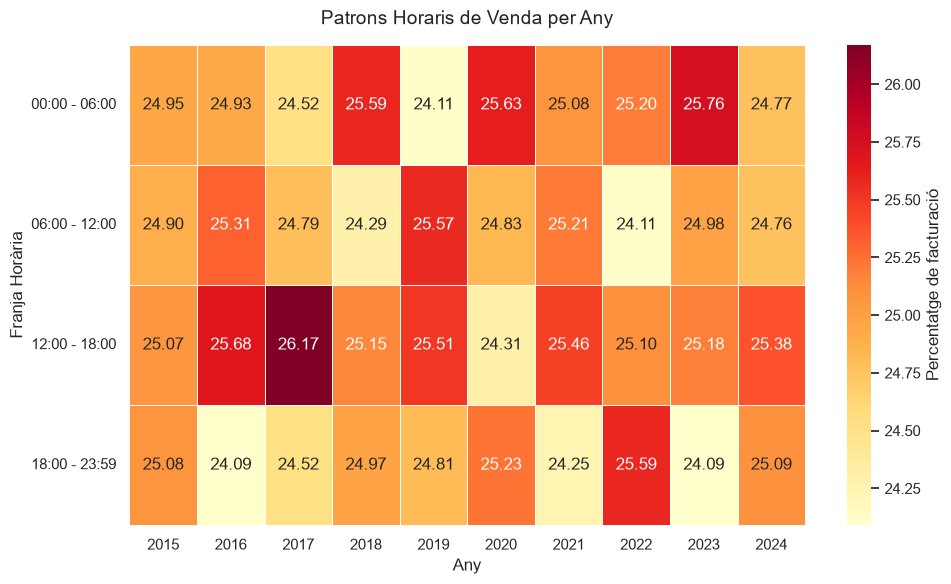

In [508]:
taula_horaria_per = generar_dades_2_4 (df_trans_acceptades)
generar_grafic_2_4 (taula_horaria_per)

🟢**Interpretació**

**» Com varia l'activitat de venda per franges horàries al llarg dels anys? (patrons horaris)**

D'entrada observem que la distribució de vendes al llarg del dia és molt uniforme en tots els anys. Podem dir que a cada franja es concentra aproximadament el 25% de la facturació. Així veiem que entre el percentatge més baix (24,09% el 2016) i el més alt (26,17% el 2017) hi ha només 2 punts de diferència.

Tot i que pels colors podria semblar el contrari no es detecten pics de venda ni hores mortes per tant podem dir que no hi ha patrons horaris i que hi ha una estabilitat en la distribució de les vendes al llarg del dia i al llarg dels anys.

# **Nivell 2 - Anàlisi relacional i patrons avançats**

# **Exercici 1: Anàlisi de productes i captació d'usuaris**

🎯 **Objectiu:** Analitzar el rendiment dels productes combinant ingressos, estabilitat i capacitat de captació de nous usuaris, amb l'objectiu de detectar possibles riscos de negoci associats a concentració excessiva d'ingressos, dependència d'usuaris recurrents i manca de creixement en base d'usuaris.
Els productes que generen més ingressos també impulsen el creixement del negoci mitjançant la captació de nous usuaris, o bé el negoci depèn principalment d'usuaris recurrents comprant els mateixos productes?

**Passos orientatius:**

1. Combina les taules necessàries.

2. Defineix un criteri de **nou usuari** si la transacció analitzada és la primera cronològicament que realitza al sistema es_nou_usuari = True / False.

3. Agrega la **informació per producte** i calcula les mètriques següents:
    *   Ingressos totals.
    *   Variabilitat dels ingressos.
    *   Nombre de nous usuaris.
    *   Percentatge de nous usuaris sobre el total de compradors del producte.

4. Creació d'una **tipologia analítica de productes** a partir de les mètriques calculades, per exemple:
    *   Captador: alta captació de nous usuaris.
    *   Recurrent: ingressos elevats però baixa captació.
    *   Emergent: baixa facturació però bona captació.
    *   Estancat: baixos ingressos i baixa captació.

5. Construeix una **visualització** que permeti analitzar la relació entre les dimensions principals. Per exemple, un scatter plot amb:
    *   Eix X → ingressos totals per producte.
    *   Eix Y → nombre de nous usuaris.
    *   Mida del punt → variabilitat dels ingressos.
    *   Color del punt → tipologia analítica del producte.

# **Disseny i implementació de la solució**

In [560]:
# 4. Tipologia analítica de productes (Segmentació per percentils/mínims)
def classificar_producte(fila, med_ing, med_capt):
    alt_ing = fila['ingressos_totals'] >= med_ing
    alta_capt = fila['per_nous_usuaris'] >= med_capt

    if alt_ing and alta_capt:
        return 'Motor de Creixement'  # Alta facturació i alta captació
    elif alt_ing and not alta_capt:
        return 'Recurrent'  # Alta facturació, dependència de clients habituals
    elif not alt_ing and alta_capt:
        return 'Emergent'  # Baixa facturació actual, però atreu nous usuaris
    else:
        return 'Estancat'  # Baixa facturació i baixa captació

In [561]:
def generar_dades (df_trans, df_prod, df_trans_prod):

  # Identifiquem la primera transacció realitzada per cada usuari
  df_trans['nou_usuari'] = df_trans.groupby('user_id')['timestamp'].transform('min') == df_trans['timestamp']

  # Combinem les dades de la taula de transaccions amb la taula pont
  df_merge = pd.merge(df_trans, df_trans_prod, left_on='id', right_on='id_transaction',how = 'inner')
  # Combinem les dades de la taula anterior amb la taula de productes
  df_merge = pd.merge(df_merge, df_prod, left_on='id_product', right_on='id',how = 'inner')

  # Agrupem per codi producte, sumem import de facturació i convertim a dataframe
  df_productes = df_merge.groupby(['id_y','product_name']).agg(
      ingressos_totals = ('amount', 'sum'),
      variabilitat = ('amount',  lambda x: np.std(x) / np.mean(x) if np.mean(x) != 0 else 0 ), # Coeficient de Variació (CV)
      total_compradors = ('user_id', 'nunique'),
      nous_usuaris = ('nou_usuari', lambda x: x.sum())
  ).reset_index()
  df_productes.columns = ['codi_producte', 'nom_prodcute','ingressos_totals','variabilitat','total_compradors','nous_usuaris']

  # Calculem el percentatge de nous usuaris respecte el total de compradors
  df_productes['per_nous_usuaris'] = (df_productes['nous_usuaris'] / df_productes['total_compradors'])*100

  # Fem servir la mitjana o mediana del resum com a llindar
  mediana_ing = df_productes['ingressos_totals'].median()
  mediana_capt = df_productes['per_nous_usuaris'].median()

  df_productes['tipologia'] = df_productes.apply(classificar_producte, axis=1,args=(mediana_ing, mediana_capt))

  # Mostrem les dades obtingudes
  mostrar_dataframe(df_productes , "MÈTRIQUES PER PRODUCTE")
  return df_productes

In [573]:
def generar_grafic (df_productes):
  # Definim les dimensions del gràfic
  plt.figure(figsize=(10, 6))

  # Dibuxem el mapa de calor
  sns.scatterplot(
      data=df_productes,
      x="ingressos_totals",
      y="nous_usuaris",
      hue = 'tipologia',
      size = "variabilitat",
      sizes = (20,200),
      legend = False)


  # Mostrem el títol del gràfic i les etiquetes dels eixos
  plt.title("Nous usuaris per producte", fontsize=14, pad=15)
  plt.xlabel("Ingressos totals per producte", fontsize=12)
  plt.ylabel("Nombre de nous usuaris", fontsize=12)
  plt.legend(title='Tipologia')

  # Rotem les etiquetes de l'eix vertical per col·locar-les de forma horitzontal
  plt.xticks(rotation=45)

  # Ajustem marges i espais del gràfic
  plt.tight_layout()
  plt.show()


MÈTRIQUES PER PRODUCTE


,codi_producte,nom_prodcute,ingressos_totals,variabilitat,total_compradors,nous_usuaris,per_nous_usuaris,tipologia
0,1,Direwolf Stannis,1008795.88,0.368671,1890,110,5.820106,Recurrent
1,2,Tarly Stark,633018.39,0.598901,1949,126,6.464854,Estancat
2,3,duel tourney Lannister,1069843.51,0.361513,1921,126,6.559084,Motor de Creixement
3,4,warden south duel,811653.93,0.467470,1945,121,6.221080,Estancat
4,5,skywalker ewok,1069200.14,0.357444,1932,152,7.867495,Motor de Creixement
...,...,...,...,...,...,...,...,...
95,96,dooku solo,670346.75,0.567296,1912,99,5.177824,Estancat
96,97,jinn Winterfell,772179.58,0.487971,1894,121,6.388596,Estancat
97,98,Direwolf Littlefinger,716499.80,0.557313,1934,120,6.204757,Estancat
98,99,the duel,998562.72,0.366399,1919,125,6.513809,Motor de Creixement


C:\Users\PC\AppData\Local\Temp\ipykernel_15432\4118092714.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Tipologia')


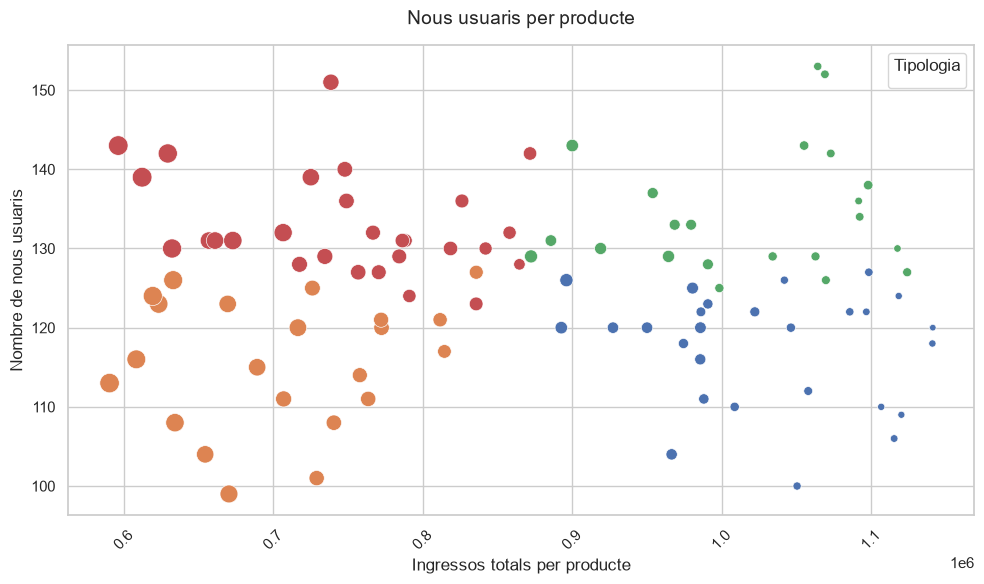

In [574]:
df_productes = generar_dades (df_trans_acceptades, df_prod, df_trans_prod)
generar_grafic (df_productes)